In [2]:
# Import libs
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Data Wrangling

In [4]:
### Read in CSV files (Core data files):

# us_csv = pd.read_csv("./Kaggle_data/USvideos.csv")
#       --------- OR ---------
url_data = "https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/Kaggle_data/AirPassengers.csv"
csv_data = pd.read_csv(url_data)

print("CSV dimensions: ", csv_data.shape,"\n")
print(csv_data.dtypes,"\n")
csv_data.head()

CSV dimensions:  (144, 2) 

Month          object
#Passengers     int64
dtype: object 



,Month,#Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [5]:
csv_data.rename(columns={'Month':'date', '#Passengers':'n_passengers'}, inplace=True)
csv_data.set_index('date', inplace=True)

# Set Frequency to avoid error when scoring ARIMA later
csv_data.index = pd.DatetimeIndex(csv_data.index.values, freq='MS')

csv_data.head()

,n_passengers
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [6]:
# Check if the file exists and remove it
filename = 'clean_passengers.pkl'
if os.path.isfile(filename):
    os.remove(filename)
csv_data.to_pickle(filename)


# If running on Google colab:
# from google.colab import files
# files.download(filename)


print(f"csv_data saved as '{filename}'")

csv_data saved as 'clean_passengers.pkl'


# 2. Data Exploration

In [7]:
# Read processed clean data (from GitHub):
filename = 'clean_passengers.pkl'
if os.path.isfile(filename):
    os.remove(filename)

!wget https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap3_AirPassengers/2_DataWrangling/clean_passengers.pkl
filtrData = pd.read_pickle(filename)

--2025-05-20 04:55:08--  https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/refs/heads/main/Cap3_AirPassengers/2_DataWrangling/clean_passengers.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3349 (3.3K) [application/octet-stream]
Saving to: ‘clean_passengers.pkl’

clean_passengers.pk 100%[===================>]   3.27K  --.-KB/s    in 0s      

2025-05-20 04:55:08 (50.7 MB/s) - ‘clean_passengers.pkl’ saved [3349/3349]



## 2.1 Check for missing/duplicate data

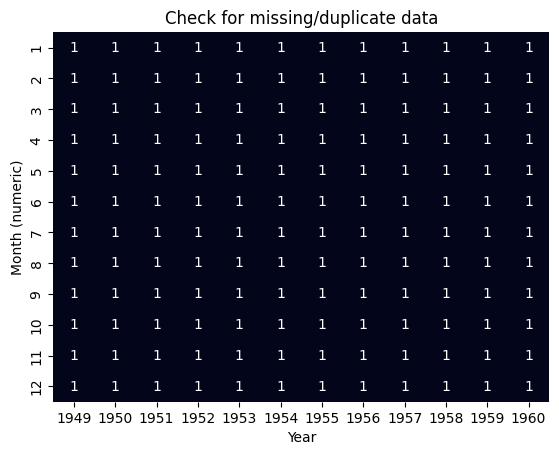

In [8]:
heat_dt1 = csv_data.copy().reset_index(names="date").\
            groupby('date', as_index=False).count().\
            rename(columns={'n_passengers':'N'})

heat_dt1["status"] = heat_dt1['N'].apply(lambda x: 1 if x==1 and x is not None else 2 if x>1 and x is not None else 0)
heat_dt1["month"]  = heat_dt1['date'].dt.month
heat_dt1["year"]   = heat_dt1['date'].dt.year

heat_dt2 = pd.DataFrame(heat_dt1, columns=['status','month','year']).set_index(['month','year']).\
            pivot_table(index='month', columns='year', values='status')

# heat_dt2.iloc[0,4] = 0
sns.heatmap(heat_dt2, annot=True, cbar=False)
plt. title("Check for missing/duplicate data")
plt.xlabel("Year")
plt.ylabel("Month (numeric)")
plt.show()

Legend for annotation:
*    0 = Data is absent (Missing data; Gaps in time series trend)
*    1 = Data present for the month
*    2 = Duplicate data identified

**No missing or dupliate data observed in data!**

## 2.2 Check for outliers

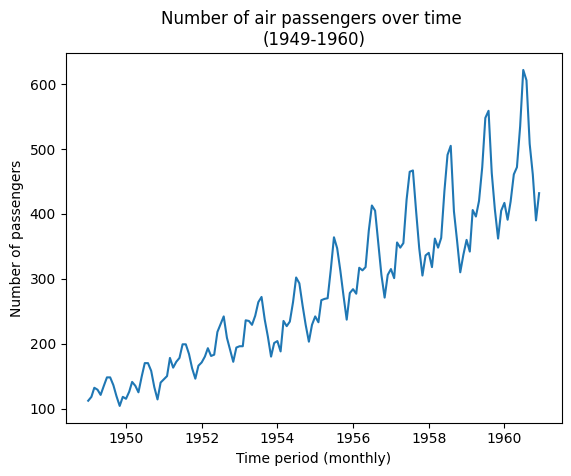

In [9]:

sns.lineplot(data=csv_data, x=csv_data.index, y="n_passengers")
plt.xlabel("Time period (monthly)")
plt.ylabel("Number of passengers")
plt.title("Number of air passengers over time \n(1949-1960)")
plt.show()

**No outiers** are seen in the time series.
Seasonality is evident in the trend (on a yearly basis), with an upward growing trend. The data is in definite need for differencing

## 2.3. Decomposition

Is it an Additive or Multiplicative model?

<Figure size 1000x700 with 0 Axes>

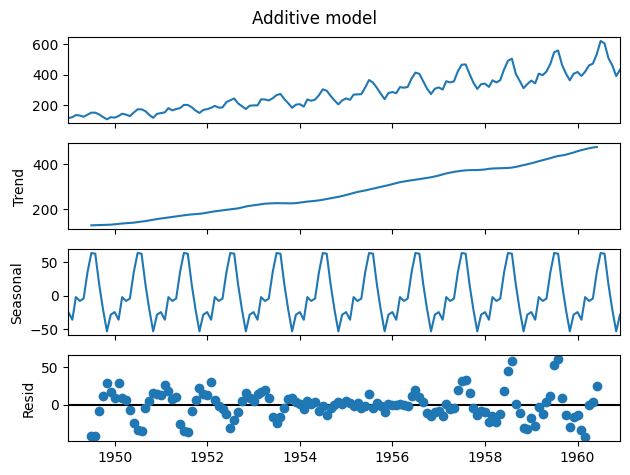

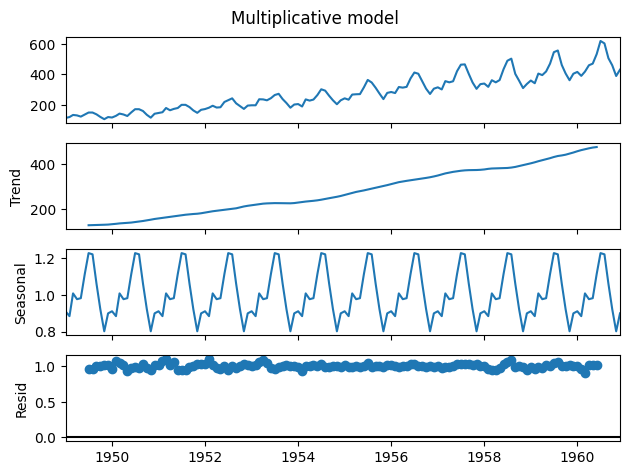

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose
plt.figure(figsize=(10, 7))
decomp1 = seasonal_decompose(csv_data['n_passengers'], period=12, model='additive')
add_fig = decomp1.plot()
for ax in add_fig.axes:
    ax.set_title("")
add_fig.suptitle("Additive model")
plt.xlabel("")
plt.show()

decomp2 = seasonal_decompose(csv_data['n_passengers'], period=12, model='multiplicative')
mul_fig = decomp2.plot()
for ax in mul_fig.axes:
    ax.set_title("")
mul_fig.suptitle("Multiplicative model")
plt.show()

The additive models still leaves behind some trends in the residuals after decomposition. Thus **multiplicative model** was chosen for decomposition!

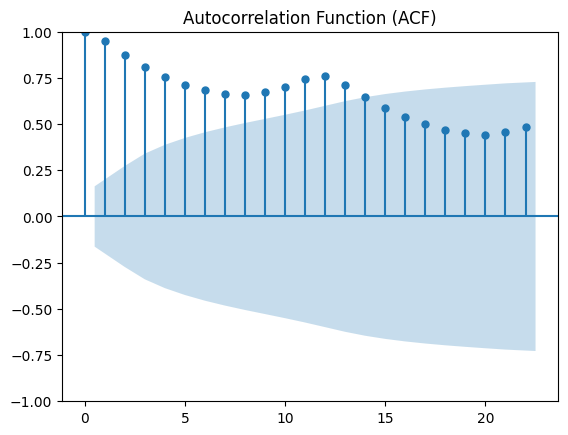

In [28]:
plot_acf(csv_data)
plt.title("Autocorrelation Function (ACF)")
plt.show()

A gradual decline is seen, indicating a **long-term dependency** (i.e. past values have a prolonged effect). Also there are many significant values observed suggesting the data is **non-stationary**.

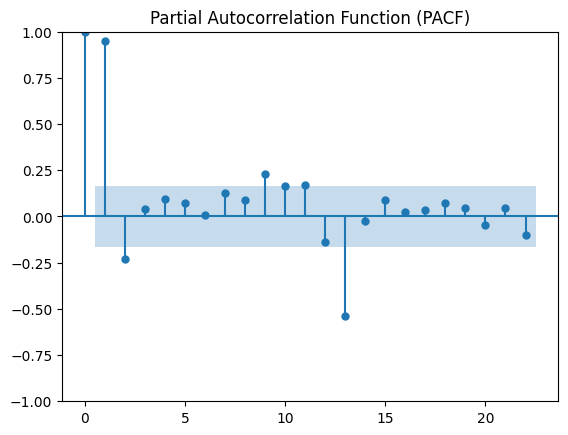

In [29]:
plot_pacf(csv_data)
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()

The data likely requires a lag-2 or AR(2) model (i.e. p=2).
Also, the PACF has isolated significant values at certain lags (1, 2, 9 & 13), it suggests those lags are important predictors for the current value.

# 3. Modelling

In [33]:
## Load packages required for modelling
import warnings
from sklearn.metrics import mean_squared_error
from joblib import dump, load

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
# from pmdarima import auto_arima

In [15]:
# Split data for Training & Testing:

Split_percentage = 0.7
split_at_n = int(np.floor(Split_percentage * csv_data.shape[0]))

train, test = csv_data[:split_at_n], csv_data[split_at_n:]

Since there are no additional features, pre-processing is very straightforward

## 3.1 ARIMA

### 3.1.1 ADF Test

In [16]:
def differencing(x, d=0, s=1):
  if d>0:
    y = x.diff(s).dropna()
    return differencing(y, d-1)
  else:
    return x

d_data = pd.DataFrame({'ADF_statistic':[],
                       'p_value':[],
                       'Crit_5%':[],
                       'AIC':[]})

for d in range(3):
  diff_data = differencing(csv_data, d)
  x1, x2, x3, x4, x5, x6 = adfuller(diff_data['n_passengers'])
  d_data.loc[d] = [x1, x2, x5['5%'], x6]
  # print(f"d({d}) = {d_data.loc[d]} \n")
diff_data = differencing(csv_data, 2)

print(d_data)

   ADF_statistic       p_value   Crit_5%         AIC
0       0.815369  9.918802e-01 -2.884042  996.692931
1      -2.829267  5.421329e-02 -2.884042  988.506932
2     -16.384232  2.732892e-29 -2.884042  988.602042


1st order differencing craetes a weakly stationary time series, while a 2nd order differencing craetes a strongly stationary time series. Thus d=2 is selected for ARIMA

3.1.1 Find the best order (= p, d, q)

Knowing a 2nd order differencing (d=2) is required, we try to find the ideal values for p & q:

In [17]:
warnings.filterwarnings("error", category=UserWarning)  # Convert UserWarning into an exception
def evaluate_arima(dt, arima_order):
  try:
    arima = ARIMA(dt, order = arima_order, freq="MS")
    arima_fit  = arima.fit()

    ## Scoring method (AIC or MSE):
    res = mean_squared_error(test, arima_fit.forecast(steps=len(test)) )
    # res = arima_fit.aic
  except:
    res = np.inf
  return res

# evaluate_arima(train, (0, 0, 2))
score_list = []
order_list = []
for p in range(4):
  for d in [2]:
    for q in range(4):
      order_result = round(evaluate_arima(train, (p, d, q)), 3);
      if order_result != np.inf:
        score_list.append(order_result)
        order_list.append((p, d, q))
        print(f"ARIMA({p}, {d}, {q}) = {order_result}")

warnings.resetwarnings()

ARIMA(0, 2, 0) = 87728.477
ARIMA(0, 2, 1) = 4895.142
ARIMA(0, 2, 2) = 5547.713
ARIMA(0, 2, 3) = 6062.88
ARIMA(1, 2, 0) = 8718.748
ARIMA(1, 2, 1) = 5039.615
ARIMA(1, 2, 2) = 5394.632
ARIMA(1, 2, 3) = 5395.779
ARIMA(2, 2, 0) = 4701.494
ARIMA(2, 2, 1) = 5778.843
ARIMA(2, 2, 2) = 5379.311
ARIMA(2, 2, 3) = 5427.481
ARIMA(3, 2, 0) = 5332.81
ARIMA(3, 2, 1) = 5789.773


Tried evaluating ARIMA model using:
*  AIC: It generates a very simplistic model (but not efficient/accurate)
*  MSE: Found to be a better scoring method, which forcasts values much better (w.r.t. AIC/BIC at least)

In [18]:
# # Alternate method for find the best order (hyperparameter testing)
# !pip install pmdarima
# import pmdarima

# # Fit Auto ARIMA to find optimal p, d, q
# auto_model = auto_arima(train['n_passengers'], m=12, seasonal=True, stepwise=False, trace=True)

# # Print optimal parameters
# print(auto_model.summary())


In [19]:
summary_dict = dict(zip(order_list, score_list))

min_value = min(summary_dict.values())
best_arima_order, best_arima_score = [(key,value) for key, value in summary_dict.items() if value == min_value][0]

print(f"Best ARIMA params (p, d, q) = {best_arima_order}. \n Score = {best_arima_score}")

Best ARIMA params (p, d, q) = (2, 2, 0). 
 Score = 4701.494


In [20]:
## Impact of 'trend'-parameter:
def evaluate_arima_trend(dt, trend, arima_order=best_arima_order):
  try:
    arima = ARIMA(dt, order = arima_order, freq="MS", trend=trend)
    arima_fit  = arima.fit()
    res = mean_squared_error(test, arima_fit.forecast(steps=len(test)) )
    # res = arima_fit.aic
  except:
    res = np.inf
  return res

for trend in ['n','c','t','ct']:
  trend_result = evaluate_arima_trend(train, trend=trend)
  # if trend_result != np.inf:
  print(f"ARIMA('{trend}') = {trend_result}")

ARIMA('n') = 4701.494456124011
ARIMA('c') = inf
ARIMA('t') = inf
ARIMA('ct') = inf


By default, ARIMA chooses trend='n' (No trend), since differencing is required for the data. So this test plays no effect on hyperparameter testing.

In [22]:
# Fit ARIMA model (p, d, q) parameters
model = ARIMA(train, order = best_arima_order)
model_fit = model.fit()

# Print summary of the model
print(model_fit.summary())

# Forecast next 10 steps
predicted = pd.DataFrame({"n_passengers" : model_fit.forecast(steps=len(test))},
                         index = test.index)

# print("Forecast:", predicted)
# predicted.index

                               SARIMAX Results                                
Dep. Variable:           n_passengers   No. Observations:                  100
Model:                 ARIMA(2, 2, 0)   Log Likelihood                -461.731
Date:                Tue, 20 May 2025   AIC                            929.463
Time:                        05:02:26   BIC                            937.218
Sample:                    01-01-1949   HQIC                           932.600
                         - 04-01-1957                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3530      0.099     -3.553      0.000      -0.548      -0.158
ar.L2         -0.3441      0.119     -2.902      0.004      -0.577      -0.112
sigma2       721.9058     94.648      7.627      0.0

<frozen importlib._bootstrap>:1047: ImportWarning: _PyDriveImportHook.find_spec() not found; falling back to find_module()
<frozen importlib._bootstrap>:1047: ImportWarning: _BokehImportHook.find_spec() not found; falling back to find_module()


(144, 1) (144, 1)


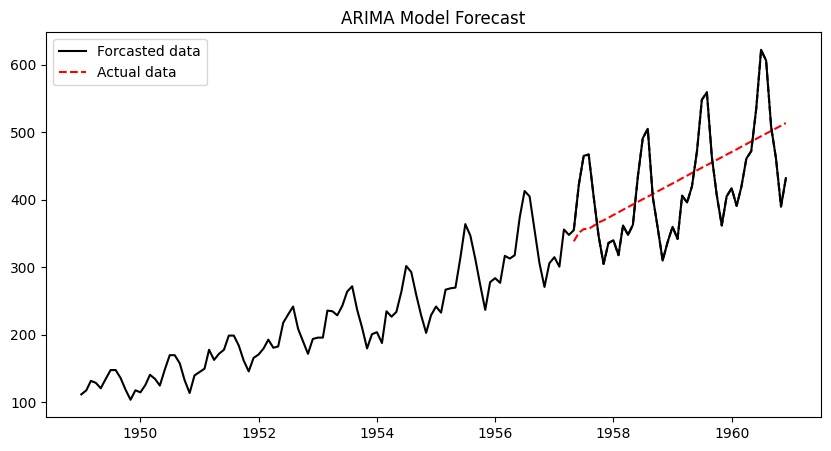

In [23]:
forecast_dt = pd.concat([train, predicted])
original_data = csv_data.copy()

print(forecast_dt.shape, original_data.shape)

# Plot actual vs forecasted values
plt.figure(figsize=(10, 5))
plt.plot(original_data.index, original_data["n_passengers"], label="Actual Data", color="black")
plt.plot(predicted.index, predicted["n_passengers"], label="Forcasted Data", linestyle="dashed", color="red")
plt.plot(test.index, test["n_passengers"], label="Forcasted Data", linestyle="--", color="black")
plt.legend(["Forcasted data", "Actual data"])
plt.title("ARIMA Model Forecast")
plt.show()

ARIMA does not take seasonality in consideration. So even though it can suitably predict the growing trending, it is not a reliable model for forcasting this data.

In [25]:
 # Check if the file exists and remove it
filename = './models/best_ARIMA.joblib'

if not os.path.isdir('models'):
    !mkdir models;
if os.path.isfile(filename):
    os.remove(filename)
dump(model_fit, filename)


# # ONLY IF running on Google colab:
from google.colab import files
files.download(filename)


print(f"ARIMA model saved as '{filename}'")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ARIMA model saved as './models/best_ARIMA.joblib'


In [39]:
# Check if the file exists and remove it
filename = './models/best_ARIMA.joblib'


# # ONLY IF running on Google colab:
# if os.path.isfile(filename):
#     os.remove(filename)
# if not os.path.isdir('models'):
#     !mkdir models;
# !wget -P ./models https://raw.githubusercontent.com/Thampi-hub/Springboard_RT/5ea29c1040625fc0ce6c182923120796e1f6ecd1/Cap3_AirPassengers/2_DataWrangling/models/best_ARIMA.joblib


arima_model = load(filename)

## 3.2 SARIMA

Continuing upon the ADF test conducted for ARIMA, we identify D (seasonal differencing) param for SARIMA.

In [34]:
def differencing(x, d=0, s=1):
  if d>0:
    y = x.diff(s).dropna()
    return differencing(y, d-1)
  else:
    return x

D_data = pd.DataFrame({'ADF_statistic':[],
                       'p_value':[],
                       'Crit_5%':[],
                       'AIC':[]})

for D in range(3):
  sdiff_data = differencing(diff_data, D, 12)
  x1, x2, x3, x4, x5, x6 = adfuller(sdiff_data['n_passengers'])
  D_data.loc[D] = [x1, x2, x5['5%'], x6]
  # print(f"D({D}) = {d_data.loc[D]} \n")
sdiff_data = differencing(diff_data, 1, 12)

print(D_data)

   ADF_statistic       p_value   Crit_5%         AIC
0     -16.384232  2.732892e-29 -2.884042  988.602042
1      -8.097600  1.326106e-12 -2.885538  929.165413
2      -6.591784  7.084690e-09 -2.887020  946.784811


In [35]:
### Based on results of ADF test:
d = 2 ## Non-seasonal differencing
D = 0 ## Seasonal differencing

### Since data is monthly seies:
m = 12

No seasonal differencing is required since data is already stationary (i.e. D=0)

In [45]:
warnings.filterwarnings("error", category=UserWarning)  # Convert UserWarning into an exception
def evaluate_sarima(dt, order, s_order):
  try:
    sarima = SARIMAX(dt, order=order, seasonal_order=s_order, freq="MS")
    sarima_fit  = sarima.fit()

    ## Scoring method (AIC or MSE):
    res = mean_squared_error(test, sarima_fit.forecast(steps=len(test)) )
    res = sarima_fit.aic
  except:
    res = np.inf
    return res

# print(evaluate_sarima(train, (1, 2, 1), (2, 0, 1, 12)))
score_list = []
order_list = []
for p in range(4):
    for q in range(4):
      for P in range(4):
        for Q in range(4):
          order_result = evaluate_sarima(train, (p, d, q), (P, D, Q, m))
          if order_result != np.inf:
            score_list.append(order_result)
            order_list.append([(p, d, q), (P, D, Q, m)])
            print(f"SARIMA({p}, {d}, {q}, {P}, {D}, {Q}, {m}) = {order_result}")

warnings.resetwarnings()

SARIMA(0, 2, 0, 0, 0, 0, 12) = None
SARIMA(0, 2, 0, 0, 0, 1, 12) = None
SARIMA(0, 2, 0, 1, 0, 0, 12) = None
SARIMA(0, 2, 1, 0, 0, 0, 12) = None
SARIMA(0, 2, 1, 0, 0, 1, 12) = None
SARIMA(0, 2, 1, 1, 0, 0, 12) = None
SARIMA(0, 2, 2, 0, 0, 0, 12) = None
SARIMA(0, 2, 2, 0, 0, 1, 12) = None
SARIMA(0, 2, 2, 1, 0, 0, 12) = None
SARIMA(0, 2, 3, 0, 0, 0, 12) = None
SARIMA(0, 2, 3, 0, 0, 1, 12) = None
SARIMA(0, 2, 3, 1, 0, 0, 12) = None
SARIMA(1, 2, 0, 0, 0, 0, 12) = None
SARIMA(1, 2, 0, 0, 0, 1, 12) = None
SARIMA(1, 2, 0, 1, 0, 0, 12) = None
SARIMA(1, 2, 1, 0, 0, 0, 12) = None
SARIMA(1, 2, 1, 0, 0, 1, 12) = None
SARIMA(1, 2, 1, 1, 0, 0, 12) = None
SARIMA(1, 2, 2, 0, 0, 0, 12) = None
SARIMA(1, 2, 2, 0, 0, 1, 12) = None
SARIMA(1, 2, 2, 1, 0, 0, 12) = None
SARIMA(1, 2, 3, 0, 0, 0, 12) = None
SARIMA(1, 2, 3, 0, 0, 1, 12) = None
SARIMA(2, 2, 0, 0, 0, 0, 12) = None
SARIMA(2, 2, 0, 0, 0, 1, 12) = None
SARIMA(2, 2, 0, 1, 0, 0, 12) = None
SARIMA(2, 2, 1, 0, 0, 0, 12) = None
SARIMA(2, 2, 1, 1, 0, 0, 12)